**Autores:** Miguel Angel Moreno, Manuel Macarro y Yasira Blanco

# **Proyecto EDA: Exploratory Data Analysis**

### Importación de Datos

Primero importamos las librerias necesarias, haremos una breve explicación del uso de cada libreria.

* `pandas`: Sirve para manipular, limpiar y analizar datos estructurados en forma de tablas (llamadas DataFrames).
* `numpy`: Sirve para realizar operaciones matemáticas y manejar arreglos numéricos de alta velocidad.
* `seaborn`: Sirve para crear gráficos estadísticos elegantes y visualmente atractivos con muy pocas líneas de código.
* `matplotlib.pyplot`: Sirve como la herramienta base para construir, personalizar y exportar gráficos en Python.
* `missingno`: Sirve para visualizar de manera rápida y gráfica dónde están los datos faltantes o nulos en tu tabla.
* `google.colab.data_table`: Sirve para transformar las tablas estáticas de pandas en tablas interactivas dentro de Google Colab (permitiendo filtrar y ordenar).
* IPython.display: Sirve para mostrar contenido enriquecido en la pantalla del cuaderno, como tablas formateadas, imágenes o código HTML.

In [ ]:
#importamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from google.colab import data_table
from IPython.display import display

# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Librerías listas para la limpieza.")


Librerías listas para la limpieza.


#### Carga del Dataset

Cargamos el dataset `all-states-history.csv`que trata sobre varios datos relacionados con el `covid`tanto datos positivos como negativos, aunque es cierto que no fue una época positiva que vivimos.

Además tambien guardamos una copia de los datos sin limpiar.

In [ ]:
df_data = pd.read_csv('all-states-history.csv')
df_data_raw = df_data.copy()
df_data

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1731628.0,0.0
1,2021-03-07,AL,10148,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347.0,NaN,NaN,119757.0,NaN,2323788.0,2347.0,NaN,0.0
2,2021-03-07,AR,5319,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380.0,NaN,NaN,NaN,481311.0,NaN,0.0,2736442.0,3380.0
3,2021-03-07,AS,0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,2140.0,0.0
4,2021-03-07,AZ,16328,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110.0,580569.0,NaN,444089.0,NaN,3842945.0,14856.0,7908105.0,45110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7142,2020-10-31,NC,4378,4301.0,46,77.0,NaN,NaN,1184.0,0,...,4025732.0,42087.0,NaN,32124.0,NaN,NaN,NaN,0.0,4025732.0,42087.0
7143,2020-10-31,ND,529,NaN,12,NaN,1618.0,1618.0,309.0,32,...,832109.0,8782.0,10846.0,735.0,NaN,NaN,294064.0,2126.0,866805.0,9303.0
7144,2020-10-31,NE,646,NaN,9,NaN,3033.0,3033.0,584.0,56,...,938123.0,17459.0,NaN,NaN,NaN,NaN,591333.0,4923.0,938123.0,17459.0
7145,2020-10-31,NH,483,NaN,1,NaN,779.0,779.0,42.0,2,...,616594.0,6670.0,33039.0,NaN,32170.0,NaN,345085.0,6389.0,616594.0,6670.0


Utilizamos `describe`para obtener un resumen estadístico rápido de las columnas numéricas.

In [ ]:
df_data.describe()

,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,inIcuCumulative,inIcuCurrently,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
count,7147.000000,3882.000000,7147.000000,3446.000000,4595.000000,4595.000000,6764.000000,7147.000000,1533.000000,5323.000000,...,7.146000e+03,7146.000000,2.088000e+03,2.370000e+03,1024.000000,639.000000,3.480000e+03,7.146000e+03,5.237000e+03,7.146000e+03
mean,6346.781447,5622.971664,41.020428,643.889147,16336.278781,16336.278781,1721.851863,57.724220,3042.842140,423.493894,...,4.622819e+06,29993.246432,2.368277e+05,4.308049e+05,214706.364258,240013.636933,1.695906e+06,3.474740e+03,4.674739e+06,2.227781e+04
std,8235.393965,4849.508496,80.139190,610.251941,16302.930707,16302.930707,2566.895553,121.718812,2347.839238,648.659163,...,6.462454e+06,48369.130464,2.500058e+05,4.567912e+05,212138.237438,129159.862239,1.855692e+06,1.463533e+04,6.331403e+06,5.475677e+04
min,0.000000,2.000000,-174.000000,1.000000,4.000000,4.000000,2.000000,-916.000000,255.000000,0.000000,...,1.616000e+03,-130545.000000,2.060000e+02,5.000000e+00,32170.000000,29401.000000,1.608500e+04,-1.043744e+06,1.616000e+03,-1.305450e+05
25%,1020.000000,1623.250000,2.000000,217.000000,4326.500000,4326.500000,299.750000,0.000000,1205.000000,64.000000,...,1.020461e+06,3797.750000,3.804800e+04,9.808000e+04,85602.000000,141209.500000,4.047175e+05,0.000000e+00,1.027509e+06,0.000000e+00
50%,3514.000000,4568.500000,16.000000,397.000000,11463.000000,11463.000000,895.000000,4.000000,2273.000000,238.000000,...,2.477046e+06,12782.000000,1.139140e+05,2.657960e+05,130696.000000,222261.000000,1.109544e+06,0.000000e+00,2.547600e+06,5.735000e+03
75%,7704.000000,7806.000000,47.000000,934.250000,22138.500000,22138.500000,2000.250000,75.000000,4722.000000,474.000000,...,5.642436e+06,36711.000000,4.118895e+05,6.479528e+05,228488.500000,326627.000000,2.462310e+06,3.546500e+03,6.005403e+06,2.571375e+04
max,54124.000000,21177.000000,2559.000000,2594.000000,82237.000000,82237.000000,22851.000000,3909.000000,9263.000000,4971.000000,...,4.964601e+07,473076.000000,1.054711e+06,2.664340e+06,995580.000000,580372.000000,1.124825e+07,1.022010e+05,4.964601e+07,2.164543e+06


##### Funciones para hacer radiografía inicial



Hemos creado unas funciones que nos permite de forma mas rápida saber que datos tenemos que limpiar y una ultima función para comparar el estado inicial del dataset con el estado final.

In [ ]:
# Se realiza un análisis técnico , "data quality check" para analizar el dataset de forma automática y entender su calidad

# Función 1 :radiografía técnica
def radiografia_tecnica(df):
    print("="*60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("="*60)

    # 1. Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)" if df.size > 0 else "  • Datos faltantes: 0")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Ejemplo de datos
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                           {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show()


# Función 2: El plan de acción (Resumen adaptado)
def plan_accion_datos(df):
    print("\n" + "="*60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("="*60)

    # Duplicados
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    # Nulos
    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    # Montos (amount)
    if 'amount' in df.columns:
        anomalos = (df['amount'] < 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Revisar {anomalos} registros con 'amount' negativo.")

    # Fechas (Específicas de tu tabla: rental_date, return_date)
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    cols_a_convertir = [col for col in cols_fecha if not pd.api.types.is_datetime64_any_dtype(df[col])]

    if cols_a_convertir:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_a_convertir}")

    print("-" * 60)
    print("  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.")
    print("="*60)

# Función 3: Comparativo Snapshot (Sin cambios, es universal)
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    def get_metrics(df):
        return [
            f"{len(df):,}",
            df.shape[1],
            f"{df.isnull().sum().sum():,}",
            f"{(df.isnull().sum().sum() / df.size * 100 if df.size > 0 else 0):.2f}%",
            df.duplicated().sum(),
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]

    metrics = {
        'Métrica': ['Filas Totales', 'Columnas', 'Celdas con Nulos', '% Global de Nulos', 'Filas Duplicadas', 'Memoria (MB)'],
        'Snapshot Inicial': get_metrics(df_inicial),
        'Snapshot Final': get_metrics(df_final)
    }

    comparativa_df = pd.DataFrame(metrics)

    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

Hacemos una llamada de las dos primeras funciones para saber que datos tenemos que analizar.

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 7,147
  • Columnas: 41
  • Celdas totales: 293,027
  • Datos faltantes: 117,014 (39.93%)
  • Filas duplicadas: 0
  • Uso de memoria: 2.88 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
date,object,7147,0,0.00%,128,1.79%,2021-03-07
state,object,7147,0,0.00%,56,0.78%,AK
death,int64,7147,0,0.00%,4755,66.53%,305
deathConfirmed,float64,3882,3265,45.68%,3015,42.19%,7963.000000
deathIncrease,int64,7147,0,0.00%,376,5.26%,0
deathProbable,float64,3446,3701,51.78%,1278,17.88%,2185.000000
hospitalized,float64,4595,2552,35.71%,3645,51.00%,1293.000000
hospitalizedCumulative,float64,4595,2552,35.71%,3645,51.00%,1293.000000
hospitalizedCurrently,float64,6764,383,5.36%,3009,42.10%,33.000000
hospitalizedIncrease,int64,7147,0,0.00%,482,6.74%,0


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
death,7147.0,6.346781e+03,8.235394e+03,0.0,1020.00,3514.0,7704.00,54124.0
deathConfirmed,3882.0,5.622972e+03,4.849508e+03,2.0,1623.25,4568.5,7806.00,21177.0
deathIncrease,7147.0,4.102043e+01,8.013919e+01,-174.0,2.00,16.0,47.00,2559.0
deathProbable,3446.0,6.438891e+02,6.102519e+02,1.0,217.00,397.0,934.25,2594.0
hospitalized,4595.0,1.633628e+04,1.630293e+04,4.0,4326.50,11463.0,22138.50,82237.0
hospitalizedCumulative,4595.0,1.633628e+04,1.630293e+04,4.0,4326.50,11463.0,22138.50,82237.0
hospitalizedCurrently,6764.0,1.721852e+03,2.566896e+03,2.0,299.75,895.0,2000.25,22851.0
hospitalizedIncrease,7147.0,5.772422e+01,1.217188e+02,-916.0,0.00,4.0,75.00,3909.0
inIcuCumulative,1533.0,3.042842e+03,2.347839e+03,255.0,1205.00,2273.0,4722.00,9263.0
inIcuCurrently,5323.0,4.234939e+02,6.486592e+02,0.0,64.00,238.0,474.00,4971.0


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


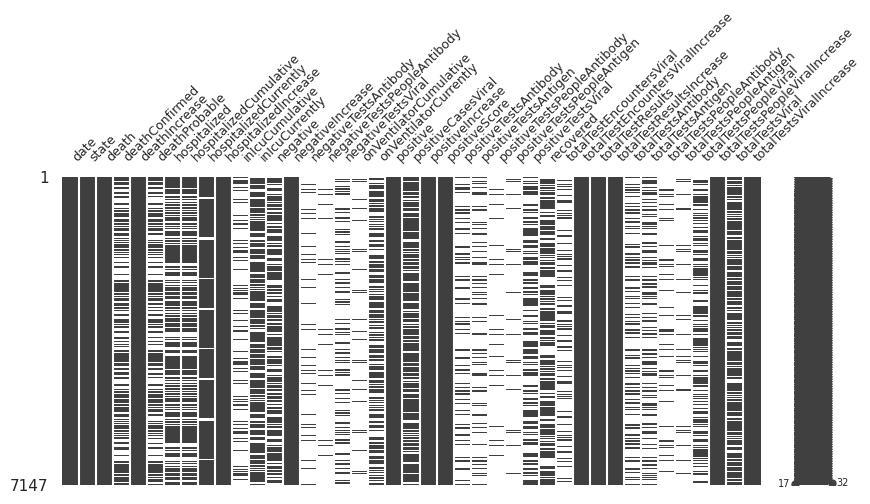


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] NULOS: Revisar columnas con >30% de vacío: ['deathConfirmed', 'deathProbable', 'hospitalized', 'hospitalizedCumulative', 'inIcuCumulative', 'negative', 'negativeTestsAntibody', 'negativeTestsPeopleAntibody', 'negativeTestsViral', 'onVentilatorCumulative', 'onVentilatorCurrently', 'positiveTestsAntibody', 'positiveTestsAntigen', 'positiveTestsPeopleAntibody', 'positiveTestsPeopleAntigen', 'positiveTestsViral', 'recovered', 'totalTestEncountersViral', 'totalTestsAntibody', 'totalTestsAntigen', 'totalTestsPeopleAntibody', 'totalTestsPeopleAntigen', 'totalTestsPeopleViral']
  [ ] FORMATO: Convertir a datetime: ['date']
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.


In [ ]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df_data)

# Para ver qué deberías limpiar:
plan_accion_datos(df_data)

### Limpieza de datos

En este apartado aplicaremos diferentes métodos para la limpieza del dataset.

#### Comprobacion de nulos

Comprobamos cuantos nulos tiene nuestro dataset.

In [ ]:
df_data.isnull().sum()

,0
date,0
state,0
death,0
deathConfirmed,3265
deathIncrease,0
deathProbable,3701
hospitalized,2552
hospitalizedCumulative,2552
hospitalizedCurrently,383
hospitalizedIncrease,0


Con la función anterior comprobamos que tenemos varios valores nulos.

Acto seguido utilizamos `info` para comprobar cómo está construida la base de datos por detrás diciendonos el tipo de datos y si hay datos nulos entre otra información importante.

In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7147 entries, 0 to 7146
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              7147 non-null   object 
 1   state                             7147 non-null   object 
 2   death                             7147 non-null   int64  
 3   deathConfirmed                    3882 non-null   float64
 4   deathIncrease                     7147 non-null   int64  
 5   deathProbable                     3446 non-null   float64
 6   hospitalized                      4595 non-null   float64
 7   hospitalizedCumulative            4595 non-null   float64
 8   hospitalizedCurrently             6764 non-null   float64
 9   hospitalizedIncrease              7147 non-null   int64  
 10  inIcuCumulative                   1533 non-null   float64
 11  inIcuCurrently                    5323 non-null   float64
 12  negati

Mostramos las 20 primeras filas con `head` para poder visualizar un pequeño porcentaje de los datos.



In [ ]:
df_data.head(20)

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1731628.0,0.0
1,2021-03-07,AL,10148,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347.0,NaN,NaN,119757.0,NaN,2323788.0,2347.0,NaN,0.0
2,2021-03-07,AR,5319,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380.0,NaN,NaN,NaN,481311.0,NaN,0.0,2736442.0,3380.0
3,2021-03-07,AS,0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,2140.0,0.0
4,2021-03-07,AZ,16328,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110.0,580569.0,NaN,444089.0,NaN,3842945.0,14856.0,7908105.0,45110.0
5,2021-03-07,CA,54124,NaN,258,NaN,NaN,NaN,4291.0,0,...,49646014.0,133186.0,NaN,NaN,NaN,NaN,NaN,0.0,49646014.0,133186.0
6,2021-03-07,CO,5989,5251.0,3,735.0,23904.0,23904.0,326.0,18,...,6415123.0,38163.0,435053.0,NaN,NaN,NaN,2616541.0,6107.0,NaN,0.0
7,2021-03-07,CT,7704,6327.0,0,1377.0,NaN,NaN,428.0,0,...,6520366.0,0.0,NaN,396680.0,NaN,NaN,NaN,0.0,6520366.0,0.0
8,2021-03-07,DC,1030,NaN,0,NaN,NaN,NaN,150.0,0,...,1261363.0,5726.0,NaN,NaN,NaN,NaN,441942.0,1149.0,NaN,0.0
9,2021-03-07,DE,1473,1337.0,9,136.0,NaN,NaN,104.0,0,...,1431942.0,5867.0,NaN,NaN,NaN,NaN,633424.0,1132.0,NaN,0.0


Hemos decidido modificar los campos `state` y `date` para que estuvieran correctamente formateados.

En el caso de `state` queriamos quitarle los espacios al principio y al final y asegurarnos que esten en mayúscula.

En el caso de `date` ya que estaba formateado como `object` lo hemos formateado de forma correcta en formato fecha.

In [ ]:
df_data['state'] = df_data['state'].str.strip().str.upper()      # Elimina espacios sobrantes y transformamos a mayúsculas.

In [ ]:
df_data['date'] = pd.to_datetime(df_data['date'])

Comprobacion de duplicados

Hemos comprobado que no habia datos duplicados.

In [ ]:
df_data.duplicated().sum()

np.int64(0)

Detectamos un problema y es que habia muchos datos con `NaN`asi que hemos decidido que dichos datos los vamos a cambiar por 0 en vez de hacer la media y el promedio.

De momento como no sabemos si esos datos van a ser necesarios, decidimos que fuera asi porque antes de inventarnos los datos preferimos dejarlos a `0` para que no afectara tanto la falta de datos a la hora de los cálculos.

In [ ]:
df_data = df_data.fillna(0)

In [ ]:
df_data

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305,0.0,0,0.0,1293.0,1293.0,33.0,0,...,1731628.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1731628.0,0.0
1,2021-03-07,AL,10148,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347.0,0.0,0.0,119757.0,0.0,2323788.0,2347.0,0.0,0.0
2,2021-03-07,AR,5319,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380.0,0.0,0.0,0.0,481311.0,0.0,0.0,2736442.0,3380.0
3,2021-03-07,AS,0,0.0,0,0.0,0.0,0.0,0.0,0,...,2140.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2140.0,0.0
4,2021-03-07,AZ,16328,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110.0,580569.0,0.0,444089.0,0.0,3842945.0,14856.0,7908105.0,45110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7142,2020-10-31,NC,4378,4301.0,46,77.0,0.0,0.0,1184.0,0,...,4025732.0,42087.0,0.0,32124.0,0.0,0.0,0.0,0.0,4025732.0,42087.0
7143,2020-10-31,ND,529,0.0,12,0.0,1618.0,1618.0,309.0,32,...,832109.0,8782.0,10846.0,735.0,0.0,0.0,294064.0,2126.0,866805.0,9303.0
7144,2020-10-31,NE,646,0.0,9,0.0,3033.0,3033.0,584.0,56,...,938123.0,17459.0,0.0,0.0,0.0,0.0,591333.0,4923.0,938123.0,17459.0
7145,2020-10-31,NH,483,0.0,1,0.0,779.0,779.0,42.0,2,...,616594.0,6670.0,33039.0,0.0,32170.0,0.0,345085.0,6389.0,616594.0,6670.0


#### Comprobación de cambios de formatos

Verificamos que los cambios de formato se hayan realizado correctamente con `dytpes`

In [ ]:
df_data.dtypes

,0
date,datetime64[ns]
state,object
death,int64
deathConfirmed,float64
deathIncrease,int64
deathProbable,float64
hospitalized,float64
hospitalizedCumulative,float64
hospitalizedCurrently,float64
hospitalizedIncrease,int64


Hacemos mas comprobaciones de formatos de datos y de los datos.

In [ ]:
df_data.info()
df_data.head()
df_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7147 entries, 0 to 7146
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              7147 non-null   datetime64[ns]
 1   state                             7147 non-null   object        
 2   death                             7147 non-null   int64         
 3   deathConfirmed                    7147 non-null   float64       
 4   deathIncrease                     7147 non-null   int64         
 5   deathProbable                     7147 non-null   float64       
 6   hospitalized                      7147 non-null   float64       
 7   hospitalizedCumulative            7147 non-null   float64       
 8   hospitalizedCurrently             7147 non-null   float64       
 9   hospitalizedIncrease              7147 non-null   int64         
 10  inIcuCumulative                   7147 non-null 

Index(['date', 'state', 'death', 'deathConfirmed', 'deathIncrease',
       'deathProbable', 'hospitalized', 'hospitalizedCumulative',
       'hospitalizedCurrently', 'hospitalizedIncrease', 'inIcuCumulative',
       'inIcuCurrently', 'negative', 'negativeIncrease',
       'negativeTestsAntibody', 'negativeTestsPeopleAntibody',
       'negativeTestsViral', 'onVentilatorCumulative', 'onVentilatorCurrently',
       'positive', 'positiveCasesViral', 'positiveIncrease', 'positiveScore',
       'positiveTestsAntibody', 'positiveTestsAntigen',
       'positiveTestsPeopleAntibody', 'positiveTestsPeopleAntigen',
       'positiveTestsViral', 'recovered', 'totalTestEncountersViral',
       'totalTestEncountersViralIncrease', 'totalTestResults',
       'totalTestResultsIncrease', 'totalTestsAntibody', 'totalTestsAntigen',
       'totalTestsPeopleAntibody', 'totalTestsPeopleAntigen',
       'totalTestsPeopleViral', 'totalTestsPeopleViralIncrease',
       'totalTestsViral', 'totalTestsViralIncrease'

Utilizamos las funciones creadas anteriormente y tambien la tercera para comprobar y ver la diferencia despues de haber limpiado y tratado los datos.

La tercera función nos permite hacer esa comprobación.

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 7,147
  • Columnas: 41
  • Celdas totales: 293,027
  • Datos faltantes: 0 (0.00%)
  • Filas duplicadas: 0
  • Uso de memoria: 2.53 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
date,datetime64[ns],7147,0,0.00%,128,1.79%,2021-03-07 00:00:00
state,object,7147,0,0.00%,56,0.78%,AK
death,int64,7147,0,0.00%,4755,66.53%,305
deathConfirmed,float64,7147,0,0.00%,3016,42.20%,0.000000
deathIncrease,int64,7147,0,0.00%,376,5.26%,0
deathProbable,float64,7147,0,0.00%,1279,17.90%,0.000000
hospitalized,float64,7147,0,0.00%,3646,51.01%,1293.000000
hospitalizedCumulative,float64,7147,0,0.00%,3646,51.01%,1293.000000
hospitalizedCurrently,float64,7147,0,0.00%,3010,42.12%,33.000000
hospitalizedIncrease,int64,7147,0,0.00%,482,6.74%,0


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,min,25%,50%,75%,max,std
date,7147,2021-01-02 16:28:40.666013696,2020-10-31 00:00:00,2020-12-02 00:00:00,2021-01-03 00:00:00,2021-02-04 00:00:00,2021-03-07 00:00:00,NaN
death,7147.0,6346.781447,0.0,1020.0,3514.0,7704.0,54124.0,8235.393965
deathConfirmed,7147.0,3054.201203,0.0,0.0,222.0,4992.5,21177.0,4540.830836
deathIncrease,7147.0,41.020428,-174.0,2.0,16.0,47.0,2559.0,80.13919
deathProbable,7147.0,310.457814,0.0,0.0,0.0,376.5,2594.0,532.037553
hospitalized,7147.0,10503.036379,0.0,0.0,3782.0,15372.0,82237.0,15236.232578
hospitalizedCumulative,7147.0,10503.036379,0.0,0.0,3782.0,15372.0,82237.0,15236.232578
hospitalizedCurrently,7147.0,1629.579684,0.0,239.0,809.0,1910.0,22851.0,2527.092089
hospitalizedIncrease,7147.0,57.72422,-916.0,0.0,4.0,75.0,3909.0,121.718812
inIcuCumulative,7147.0,652.676228,0.0,0.0,0.0,0.0,9263.0,1655.89596


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


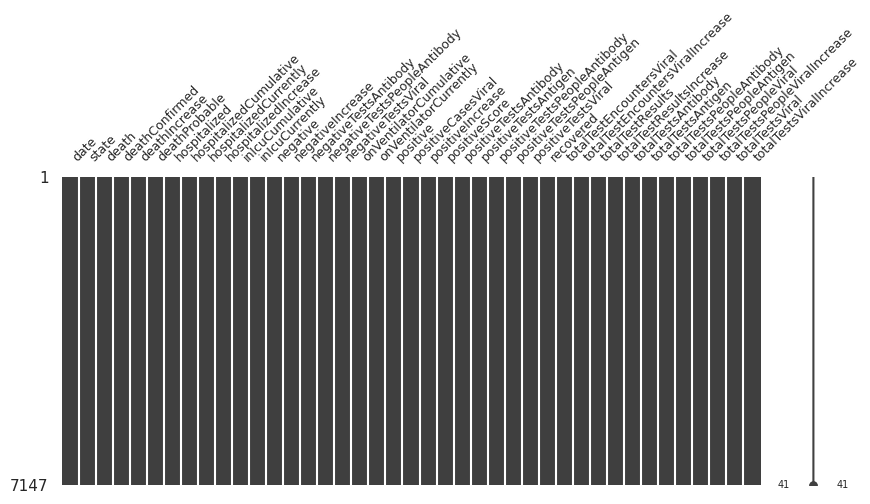


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.
             ⚖️ COMPARATIVA DE CALIDAD DE DATOS             


Métrica,Snapshot Inicial,Snapshot Final
Filas Totales,"7,147","7,147"
Columnas,41,41
Celdas con Nulos,"117,014",0
% Global de Nulos,39.93%,0.00%
Filas Duplicadas,0,0
Memoria (MB),2.88,2.53



✅ Se han depurado 0 filas en total.


In [ ]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df_data)

# Para ver qué deberías limpiar:
plan_accion_datos(df_data)

#Comparativa
comparativo_snapshot(df_data_raw, df_data)

Este bloque de código sirve para hacer una inspección rápida de los datos columna por columna, mostrándote cuáles son los 20 valores más frecuentes (y los errores más comunes) en cada una de ellas.

In [ ]:
for col in df_data.columns:
    print(f"\n--- {col} ---")
    print(df_data[col].value_counts(dropna=False).head(20))


--- date ---
date
2021-03-07    56
2021-03-06    56
2021-03-05    56
2021-03-04    56
2021-03-03    56
2021-03-02    56
2021-03-01    56
2021-02-28    56
2021-02-27    56
2021-02-26    56
2021-02-25    56
2021-02-24    56
2021-02-23    56
2021-02-22    56
2021-02-21    56
2021-02-20    56
2021-02-19    56
2021-02-18    56
2021-02-17    56
2021-02-16    56
Name: count, dtype: int64

--- state ---
state
AK    128
AL    128
AR    128
AS    128
AZ    128
CA    128
CO    128
CT    128
DC    128
DE    128
FL    128
GA    128
GU    128
HI    128
IA    128
ID    128
IL    128
IN    128
KS    128
KY    128
Name: count, dtype: int64

--- death ---
death
2      128
0      128
23      62
24      37
25      25
130     22
129     14
121     13
647     12
59      11
119      9
671      9
176      9
489      9
215      8
701      8
262      8
289      8
112      8
522      8
Name: count, dtype: int64

--- deathConfirmed ---
deathConfirmed
0.0        3265
2.0         128
59.0         11
285.0         

#REPRESENTACIÓN DE DATOS